In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [20]:
dataset_path = r"C:\Users\rutuj\Desktop\Practicals\DLpractical\PlantVillage"

print("Path exists:", os.path.exists(dataset_path))

Path exists: True


In [22]:
img_size = (128, 128)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_data.class_names
print("Classes:", class_names)

Found 1988 files belonging to 2 classes.
Using 1591 files for training.
Found 1988 files belonging to 2 classes.
Using 397 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']


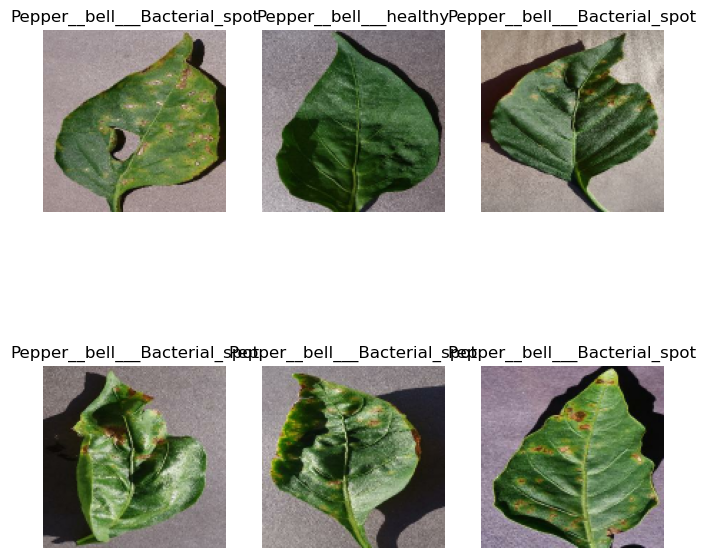

In [24]:
plt.figure(figsize=(8,8))
for images, labels in train_data.take(1):
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [26]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

C:\Users\rutuj\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 493ms/step - accuracy: 0.7040 - loss: 0.5841 - val_accuracy: 0.8841 - val_loss: 0.3376
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 460ms/step - accuracy: 0.8875 - loss: 0.2982 - val_accuracy: 0.8992 - val_loss: 0.2459
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 490ms/step - accuracy: 0.9340 - loss: 0.2043 - val_accuracy: 0.9295 - val_loss: 0.1621
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 495ms/step - accuracy: 0.9510 - loss: 0.1422 - val_accuracy: 0.9446 - val_loss: 0.1347
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 463ms/step - accuracy: 0.9705 - loss: 0.0964 - val_accuracy: 0.9471 - val_loss: 0.1373


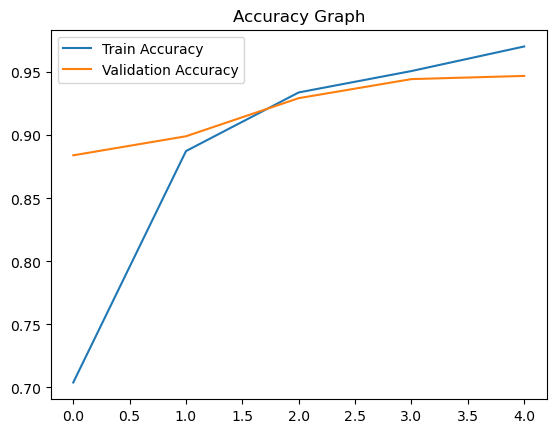

In [31]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [38]:
from tensorflow.keras.preprocessing import image

img_path = r"E:\Practicals\PlantVillage\Pepper__bell___healthy\test_leaf.jpg"

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
Predicted Disease: Pepper__bell___healthy
